In [34]:
import pandas as pd
import matplotlib.pyplot as plt


In [35]:
df = pd.read_csv('retail_store_sales.csv')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


In [37]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [38]:
df.isnull().sum()
df.duplicated().sum()  
df.drop_duplicates() 

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [39]:
df=df.dropna(subset=['Item'])
df.info()

<class 'pandas.DataFrame'>
Index: 11362 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11362 non-null  str    
 1   Customer ID       11362 non-null  str    
 2   Category          11362 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11362 non-null  float64
 5   Quantity          11362 non-null  float64
 6   Total Spent       11362 non-null  float64
 7   Payment Method    11362 non-null  str    
 8   Location          11362 non-null  str    
 9   Transaction Date  11362 non-null  str    
 10  Discount Applied  7579 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.0+ MB


In [40]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    3783
dtype: int64

In [41]:
df=df.dropna(subset=['Discount Applied'])
df.info()

<class 'pandas.DataFrame'>
Index: 7579 entries, 0 to 12573
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    7579 non-null   str    
 1   Customer ID       7579 non-null   str    
 2   Category          7579 non-null   str    
 3   Item              7579 non-null   str    
 4   Price Per Unit    7579 non-null   float64
 5   Quantity          7579 non-null   float64
 6   Total Spent       7579 non-null   float64
 7   Payment Method    7579 non-null   str    
 8   Location          7579 non-null   str    
 9   Transaction Date  7579 non-null   str    
 10  Discount Applied  7579 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 710.5+ KB


In [42]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

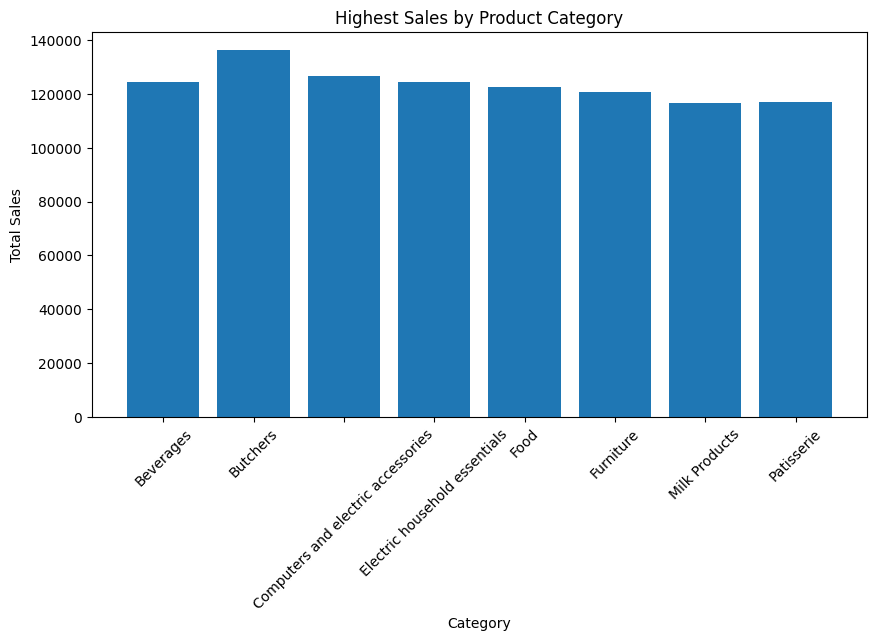

In [43]:
# total sales by category
category_sales = df.groupby("Category")["Total Spent"].sum()

# create bar chart
plt.figure(figsize=(10,5))
plt.bar(category_sales.index, category_sales.values)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Highest Sales by Product Category")

plt.xticks(rotation=45)
plt.show()

In [1]:
# total quantity sold by item
item_sales = df.groupby("Item")["Quantity"].sum()

# top 10 items
top_items = item_sales.sort_values(ascending=False).head(10)

# horizontal bar chart
plt.figure(figsize=(10,5))
plt.barh(top_items.index, top_items.values)

plt.xlabel("Quantity Sold")
plt.ylabel("Items")
plt.title("Top 10 Most Sold Items")

plt.show()

NameError: name 'df' is not defined

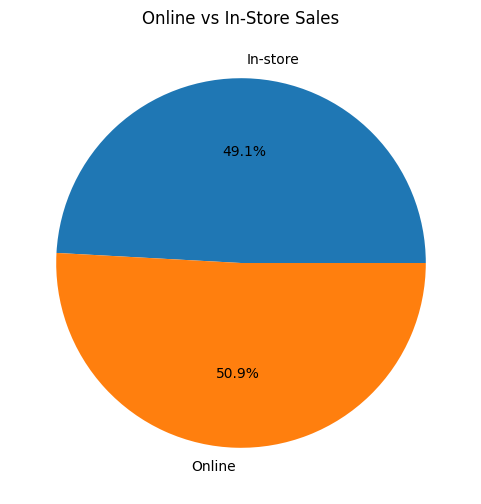

In [45]:
# sales by location
location_sales = df.groupby("Location")["Total Spent"].sum()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(
    location_sales.values,
    labels=location_sales.index,
    autopct="%1.1f%%"
)

plt.title("Online vs In-Store Sales")
plt.show()

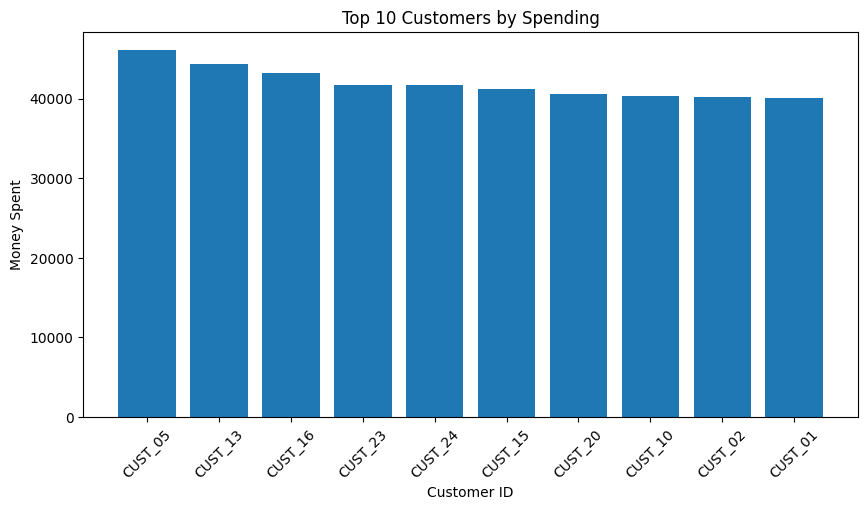

In [46]:
# total spending by customer
customer_sales = df.groupby("Customer ID")["Total Spent"].sum()

# top 10 customers
top_customers = customer_sales.sort_values(ascending=False).head(10)

# bar chart
plt.figure(figsize=(10,5))
plt.bar(top_customers.index, top_customers.values)

plt.xlabel("Customer ID")
plt.ylabel("Money Spent")
plt.title("Top 10 Customers by Spending")

plt.xticks(rotation=45)
plt.show()

In [47]:
# average quantity
avg_quantity = df["Quantity"].mean()

print("Average Quantity Purchased =", avg_quantity)

Average Quantity Purchased = 5.55732946298984


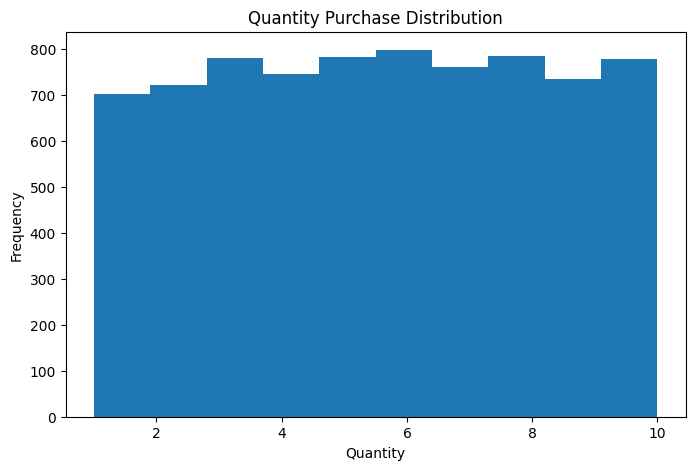

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"])

plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Quantity Purchase Distribution")

plt.show()

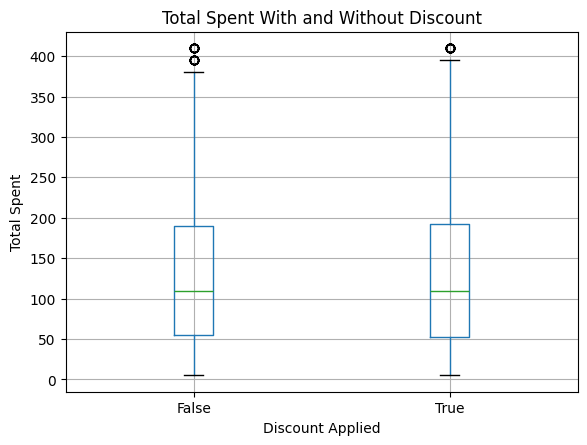

In [49]:
# remove missing values
discount_df = df.dropna(subset=["Discount Applied"])

# box plot
discount_df.boxplot(column="Total Spent", by="Discount Applied")

plt.title("Total Spent With and Without Discount")
plt.suptitle("")

plt.xlabel("Discount Applied")
plt.ylabel("Total Spent")

plt.show()

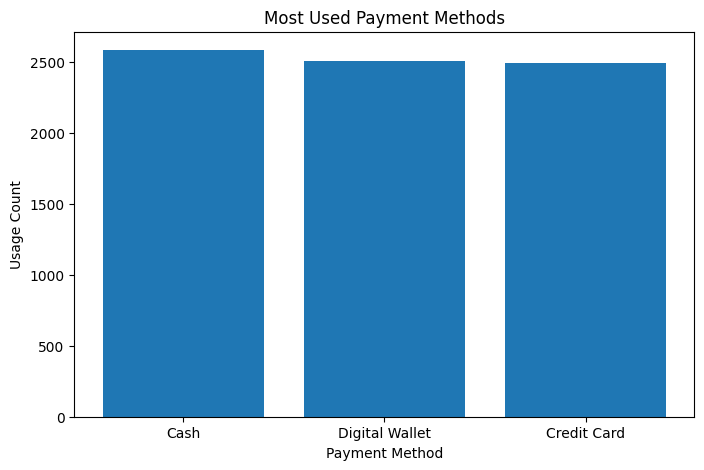

In [50]:
# count payment methods
payment_count = df["Payment Method"].value_counts()

# bar chart
plt.figure(figsize=(8,5))
plt.bar(payment_count.index, payment_count.values)

plt.xlabel("Payment Method")
plt.ylabel("Usage Count")
plt.title("Most Used Payment Methods")

plt.show()

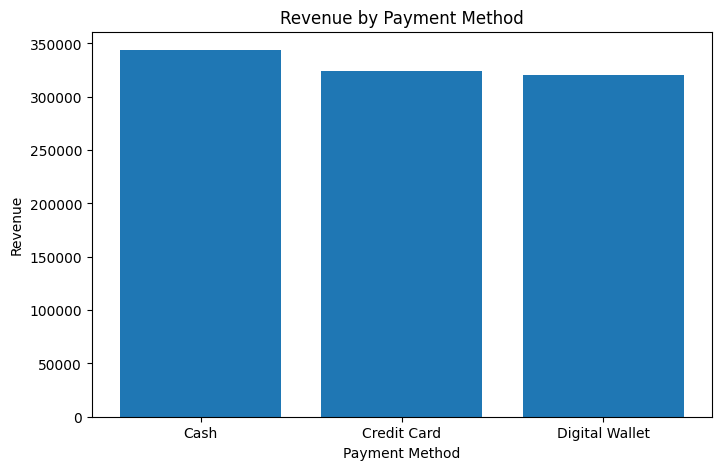

In [51]:
# revenue by payment method
payment_revenue = df.groupby("Payment Method")["Total Spent"].sum()

# bar chart
plt.figure(figsize=(8,5))
plt.bar(payment_revenue.index, payment_revenue.values)

plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.title("Revenue by Payment Method")

plt.show()

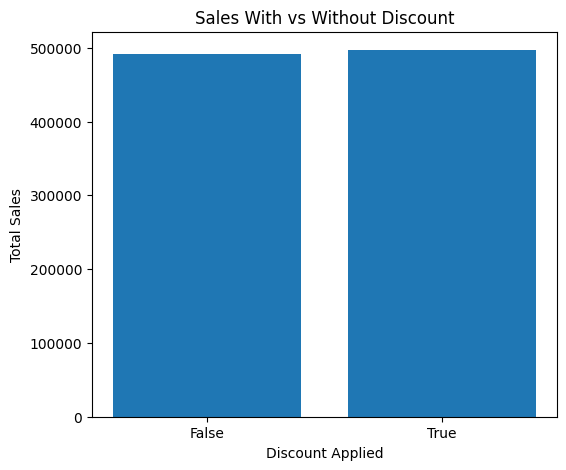

In [52]:
# remove missing values
discount_sales = df.dropna(subset=["Discount Applied"])

# total sales
sales_compare = discount_sales.groupby("Discount Applied")["Total Spent"].sum()

# grouped bar chart
plt.figure(figsize=(6,5))
plt.bar(sales_compare.index.astype(str), sales_compare.values)

plt.xlabel("Discount Applied")
plt.ylabel("Total Sales")
plt.title("Sales With vs Without Discount")

plt.show()

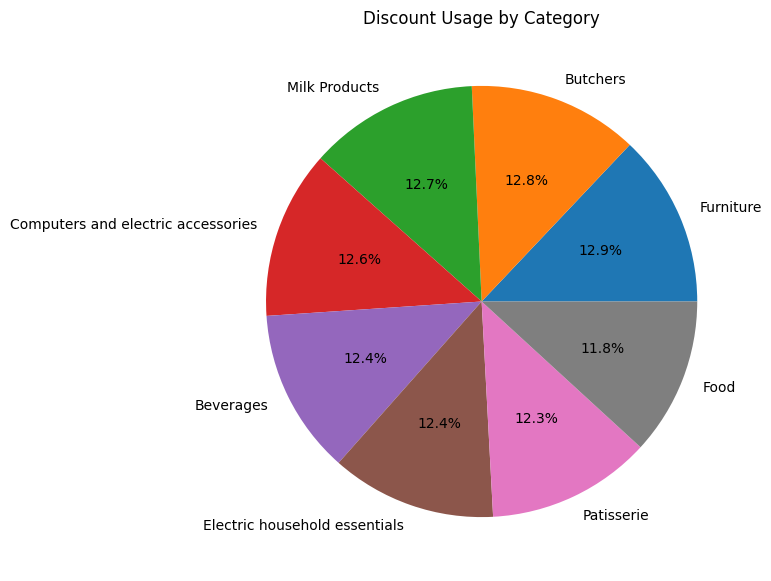

In [53]:
# count discounts by category
discount_category = df[df["Discount Applied"] == True]["Category"].value_counts()

# pie chart
plt.figure(figsize=(7,7))
plt.pie(
    discount_category.values,
    labels=discount_category.index,
    autopct="%1.1f%%"
)

plt.title("Discount Usage by Category")
plt.show()

In [54]:
# convert date column
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

print(df["Transaction Date"].head())

0   2024-04-08
1   2023-07-23
2   2022-10-05
4   2022-10-02
6   2023-06-10
Name: Transaction Date, dtype: datetime64[us]


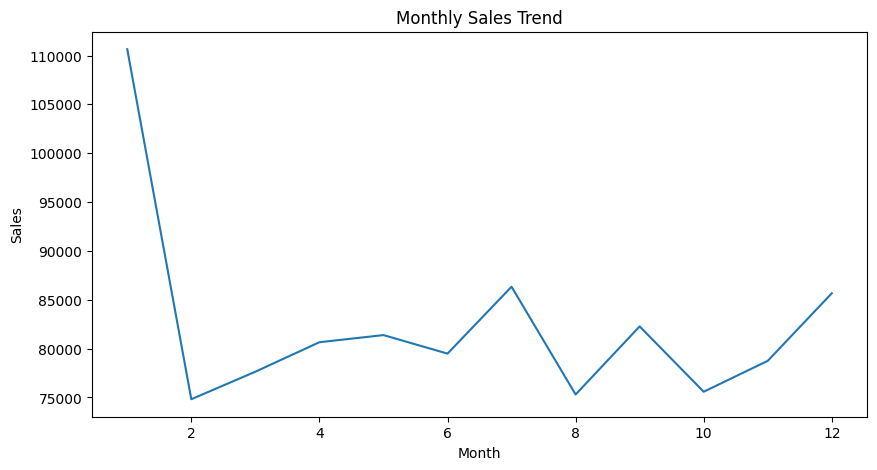

In [55]:
# extract month
df["Month"] = df["Transaction Date"].dt.month

# monthly sales
monthly_sales = df.groupby("Month")["Total Spent"].sum()

# line chart
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")

plt.show()

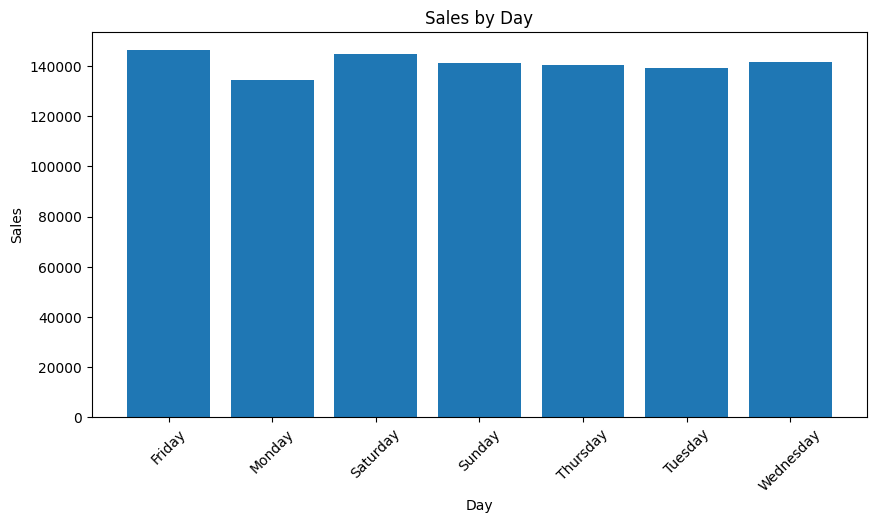

In [56]:
# extract day name
df["Day"] = df["Transaction Date"].dt.day_name()

# sales by day
day_sales = df.groupby("Day")["Total Spent"].sum()

# bar chart
plt.figure(figsize=(10,5))
plt.bar(day_sales.index, day_sales.values)

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales by Day")

plt.xticks(rotation=45)
plt.show()

In [1]:
print("Hello")

Hello


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
data=[12,15,14,10,8,7,13]
sns.boxplot(data=data)
plt.title("Box plot")
plt.ylabel("Values")